### Healthcare Insurance Claim Fraud Detection — Exploratory Data Analysis

## Objective

The objective of this EDA is to understand the structure, quality,
distribution, relationships, and fraud-related patterns in the
healthcare insurance claims data.

### Datasets

1. Provider / Fraud Label Dataset
2. Beneficiary Dataset
3. Inpatient Claims Dataset
4. Outpatient Claims Dataset

### Key Question

What characteristics and claim patterns distinguish potentially
fraudulent healthcare providers from non-fraudulent providers?


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [32]:
beneficiary_df = pd.read_csv("../data/raw/train/Train_Beneficiarydata-1542865627584.csv")

inpatient_df = pd.read_csv("../data/raw/train/Train_Inpatientdata-1542865627584.csv")

outpatient_df = pd.read_csv("../data/raw/train/Train_Outpatientdata-1542865627584.csv")

provider_df = pd.read_csv("../data/raw/train/Train-1542865627584.csv")

In [33]:
print("SHAPES")
print("Beneficiary:", beneficiary_df.shape)
print("Inpatient:", inpatient_df.shape)
print("Outpatient:", outpatient_df.shape)   
print("Provider:", provider_df.shape)

SHAPES
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)
Provider: (5410, 2)


In [34]:

beneficiary_df.columns.tolist()

['BeneID',
 'DOB',
 'DOD',
 'Gender',
 'Race',
 'RenalDiseaseIndicator',
 'State',
 'County',
 'NoOfMonths_PartACov',
 'NoOfMonths_PartBCov',
 'ChronicCond_Alzheimer',
 'ChronicCond_Heartfailure',
 'ChronicCond_KidneyDisease',
 'ChronicCond_Cancer',
 'ChronicCond_ObstrPulmonary',
 'ChronicCond_Depression',
 'ChronicCond_Diabetes',
 'ChronicCond_IschemicHeart',
 'ChronicCond_Osteoporasis',
 'ChronicCond_rheumatoidarthritis',
 'ChronicCond_stroke',
 'IPAnnualReimbursementAmt',
 'IPAnnualDeductibleAmt',
 'OPAnnualReimbursementAmt',
 'OPAnnualDeductibleAmt']

In [35]:
print("\nadmitted in hospital:")
inpatient_df.columns.tolist()


admitted in hospital:


['BeneID',
 'ClaimID',
 'ClaimStartDt',
 'ClaimEndDt',
 'Provider',
 'InscClaimAmtReimbursed',
 'AttendingPhysician',
 'OperatingPhysician',
 'OtherPhysician',
 'AdmissionDt',
 'ClmAdmitDiagnosisCode',
 'DeductibleAmtPaid',
 'DischargeDt',
 'DiagnosisGroupCode',
 'ClmDiagnosisCode_1',
 'ClmDiagnosisCode_2',
 'ClmDiagnosisCode_3',
 'ClmDiagnosisCode_4',
 'ClmDiagnosisCode_5',
 'ClmDiagnosisCode_6',
 'ClmDiagnosisCode_7',
 'ClmDiagnosisCode_8',
 'ClmDiagnosisCode_9',
 'ClmDiagnosisCode_10',
 'ClmProcedureCode_1',
 'ClmProcedureCode_2',
 'ClmProcedureCode_3',
 'ClmProcedureCode_4',
 'ClmProcedureCode_5',
 'ClmProcedureCode_6']

In [36]:
print("visits to hospital:")
outpatient_df.columns.tolist()

visits to hospital:


['BeneID',
 'ClaimID',
 'ClaimStartDt',
 'ClaimEndDt',
 'Provider',
 'InscClaimAmtReimbursed',
 'AttendingPhysician',
 'OperatingPhysician',
 'OtherPhysician',
 'ClmDiagnosisCode_1',
 'ClmDiagnosisCode_2',
 'ClmDiagnosisCode_3',
 'ClmDiagnosisCode_4',
 'ClmDiagnosisCode_5',
 'ClmDiagnosisCode_6',
 'ClmDiagnosisCode_7',
 'ClmDiagnosisCode_8',
 'ClmDiagnosisCode_9',
 'ClmDiagnosisCode_10',
 'ClmProcedureCode_1',
 'ClmProcedureCode_2',
 'ClmProcedureCode_3',
 'ClmProcedureCode_4',
 'ClmProcedureCode_5',
 'ClmProcedureCode_6',
 'DeductibleAmtPaid',
 'ClmAdmitDiagnosisCode']

In [37]:
print("provider data:")
provider_df.columns.tolist()

provider data:


['Provider', 'PotentialFraud']

In [38]:
provider_df.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [39]:
beneficiary_df.head(2)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50


In [40]:
inpatient_df.head(2)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN


In [41]:
outpatient_df.head(2)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380


# How are these four datasets connected?

In [47]:
#PROVIDER ID CONNECTS ALL DATASETS PROVIDER ID ->INPATIENT/OUTPATIENT -> BENEFICIARY

print("Provider ID connects all datasets: Provider ID -> Inpatient/Outpatient -> Beneficiary")

print(provider_df['Provider'].head())
print(inpatient_df['Provider'].head())
print(outpatient_df['Provider'].head())


Provider ID connects all datasets: Provider ID -> Inpatient/Outpatient -> Beneficiary
0    PRV51001
1    PRV51003
2    PRV51004
3    PRV51005
4    PRV51007
Name: Provider, dtype: str
0    PRV55912
1    PRV55907
2    PRV56046
3    PRV52405
4    PRV56614
Name: Provider, dtype: str
0    PRV56011
1    PRV57610
2    PRV57595
3    PRV56011
4    PRV56011
Name: Provider, dtype: str


In [43]:
print("bene ID connects inpatient and outpatient datasets: Bene ID -> Inpatient/Outpatient")

print(inpatient_df['BeneID'].head())
print(outpatient_df['BeneID'].head())
print(beneficiary_df['BeneID'].head())

bene ID connects inpatient and outpatient datasets: Bene ID -> Inpatient/Outpatient
0    BENE11001
1    BENE11001
2    BENE11001
3    BENE11011
4    BENE11014
Name: BeneID, dtype: str
0    BENE11002
1    BENE11003
2    BENE11003
3    BENE11004
4    BENE11004
Name: BeneID, dtype: str
0    BENE11001
1    BENE11002
2    BENE11003
3    BENE11004
4    BENE11005
Name: BeneID, dtype: str



#checking how many unique IDs exist

In [44]:
print("unique providers\n")

print("Provider:", provider_df['Provider'].nunique())
print("Inpatient:", inpatient_df['Provider'].nunique())
print("Outpatient:",outpatient_df['Provider'].nunique())

unique providers

Provider: 5410
Inpatient: 2092
Outpatient: 5012


In [45]:
print("unique bene IDs in inpatient and outpatient datasets:")
print("Inpatient:", inpatient_df['BeneID'].nunique())
print("Outpatient:", outpatient_df['BeneID'].nunique()) 
print("Beneficiary:", beneficiary_df['BeneID'].nunique())

unique bene IDs in inpatient and outpatient datasets:
Inpatient: 31289
Outpatient: 133980
Beneficiary: 138556


In [48]:
datasets = {
    "Provider": provider_df,
    "Beneficiary": beneficiary_df,
    "Inpatient": inpatient_df,
    "Outpatient": outpatient_df
}

In [49]:
for name, df in datasets.items():
    print(f"\n{name} data types:")
    display(df.dtypes.to_frame("dtype"))


Provider data types:


,dtype
Provider,str
PotentialFraud,str



Beneficiary data types:


,dtype
BeneID,str
DOB,str
DOD,str
Gender,int64
Race,int64
RenalDiseaseIndicator,str
State,int64
County,int64
NoOfMonths_PartACov,int64
NoOfMonths_PartBCov,int64



Inpatient data types:


,dtype
BeneID,str
ClaimID,str
ClaimStartDt,str
ClaimEndDt,str
Provider,str
InscClaimAmtReimbursed,int64
AttendingPhysician,str
OperatingPhysician,str
OtherPhysician,str
AdmissionDt,str



Outpatient data types:


,dtype
BeneID,str
ClaimID,str
ClaimStartDt,str
ClaimEndDt,str
Provider,str
InscClaimAmtReimbursed,int64
AttendingPhysician,str
OperatingPhysician,str
OtherPhysician,str
ClmDiagnosisCode_1,str


In [50]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    print(
        f"{name}: {duplicate_count:,} duplicate rows "
        f"({duplicate_count / len(df) * 100:.2f}%)"
    )

Provider: 0 duplicate rows (0.00%)
Beneficiary: 0 duplicate rows (0.00%)
Inpatient: 0 duplicate rows (0.00%)
Outpatient: 0 duplicate rows (0.00%)


In [51]:
def missing_summary(df):
    result = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percentage": df.isna().mean() * 100
    })

    return result.sort_values(
        "Missing_Percentage",
        ascending=False
    )

for name, df in datasets.items():
    print(f"\n{name}")
    display(missing_summary(df).head(20))


Provider


,Missing_Count,Missing_Percentage
Provider,0,0.0
PotentialFraud,0,0.0



Beneficiary


,Missing_Count,Missing_Percentage
DOD,137135,98.974422
BeneID,0,0.000000
DOB,0,0.000000
Gender,0,0.000000
Race,0,0.000000
RenalDiseaseIndicator,0,0.000000
State,0,0.000000
County,0,0.000000
NoOfMonths_PartACov,0,0.000000
NoOfMonths_PartBCov,0,0.000000



Inpatient


,Missing_Count,Missing_Percentage
ClmProcedureCode_6,40474,100.000000
ClmProcedureCode_5,40465,99.977764
ClmProcedureCode_4,40358,99.713396
ClmProcedureCode_3,39509,97.615753
ClmDiagnosisCode_10,36547,90.297475
OtherPhysician,35784,88.412314
ClmProcedureCode_2,35020,86.524683
ClmProcedureCode_1,17326,42.807728
OperatingPhysician,16644,41.122696
ClmDiagnosisCode_9,13497,33.347334



Outpatient


,Missing_Count,Missing_Percentage
ClmProcedureCode_5,517737,100.000000
ClmProcedureCode_6,517737,100.000000
ClmProcedureCode_4,517735,99.999614
ClmProcedureCode_3,517733,99.999227
ClmProcedureCode_2,517701,99.993047
ClmProcedureCode_1,517575,99.968710
ClmDiagnosisCode_10,516654,99.790820
ClmDiagnosisCode_9,502899,97.134066
ClmDiagnosisCode_8,494825,95.574587
ClmDiagnosisCode_7,484776,93.633640


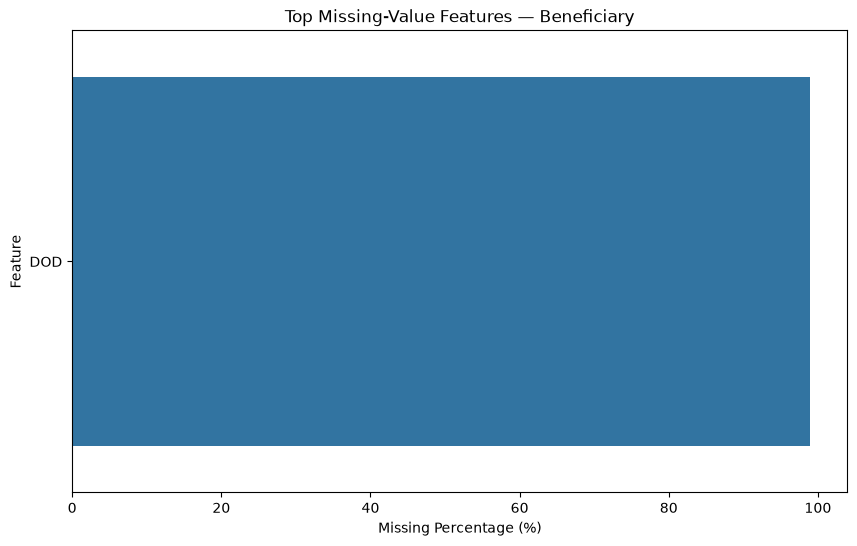

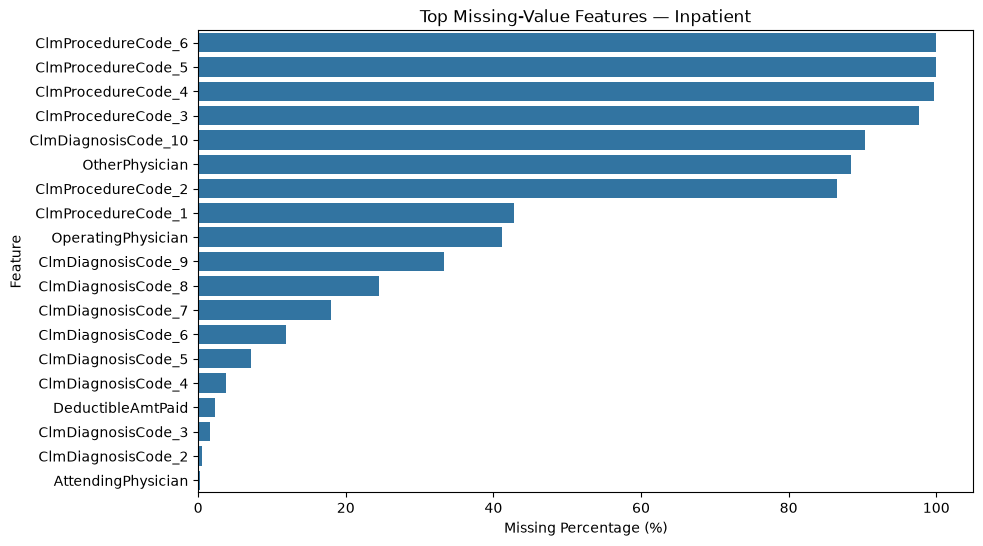

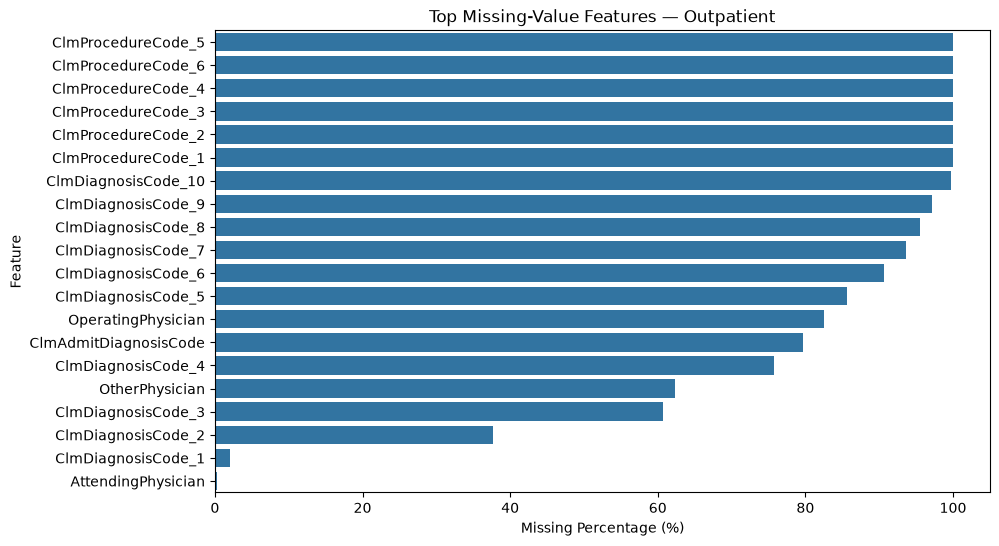

In [52]:
for name, df in datasets.items():

    missing = (
        df.isna().mean() * 100
    ).sort_values(ascending=False)

    missing = missing[missing > 0].head(20)

    if len(missing) == 0:
        continue

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=missing.values,
        y=missing.index
    )

    plt.title(f"Top Missing-Value Features — {name}")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")
    plt.show()

In [53]:
provider_df["PotentialFraud"].value_counts()

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

In [54]:
provider_df["PotentialFraud"].value_counts(normalize=True) * 100

PotentialFraud
No     90.64695
Yes     9.35305
Name: proportion, dtype: float64

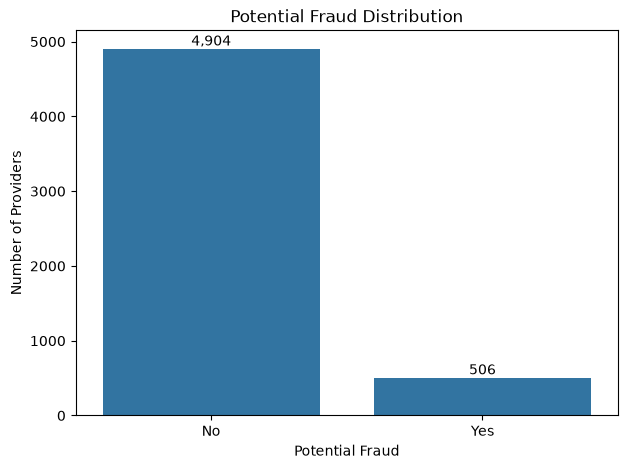

In [55]:
fraud_counts = provider_df["PotentialFraud"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title("Potential Fraud Distribution")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")

for i, value in enumerate(fraud_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

In [56]:
fraud_distribution = (
    provider_df["PotentialFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
    .to_frame()
)

fraud_distribution

,Percentage
PotentialFraud,
No,90.65
Yes,9.35


In [57]:
print("Total provider records:", len(provider_df))
print("Unique providers:", provider_df["Provider"].nunique())
print("Duplicate provider IDs:", provider_df["Provider"].duplicated().sum())

Total provider records: 5410
Unique providers: 5410
Duplicate provider IDs: 0


In [58]:
beneficiary_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BeneID,138556,138556,BENE11001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOB,138556,900,1939-10-01,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOD,1421,11,2009-12-01,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,138556.0,NaN,NaN,NaN,1.570932,0.494945,1.0,1.0,2.0,2.0,2.0
Race,138556.0,NaN,NaN,NaN,1.254511,0.717007,1.0,1.0,1.0,1.0,5.0
RenalDiseaseIndicator,138556,2,0,118978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,138556.0,NaN,NaN,NaN,25.666734,15.223443,1.0,11.0,25.0,39.0,54.0
County,138556.0,NaN,NaN,NaN,374.424745,266.277581,0.0,141.0,340.0,570.0,999.0
NoOfMonths_PartACov,138556.0,NaN,NaN,NaN,11.907727,1.032332,0.0,12.0,12.0,12.0,12.0
NoOfMonths_PartBCov,138556.0,NaN,NaN,NaN,11.910145,0.936893,0.0,12.0,12.0,12.0,12.0


In [59]:
beneficiary_df["Gender"].value_counts(dropna=False)

Gender
2    79106
1    59450
Name: count, dtype: int64

In [60]:
beneficiary_df["Race"].value_counts(dropna=False)

Race
1    117057
2     13538
3      5059
5      2902
Name: count, dtype: int64

In [61]:
beneficiary_df["State"].value_counts(dropna=False).head(20)

State
5     12052
10     9771
45     8780
33     8443
39     6055
14     5923
36     5366
23     5293
34     4629
31     4124
11     3892
49     3623
44     3390
22     3306
15     3272
26     3108
50     2793
52     2662
1      2615
21     2570
Name: count, dtype: int64

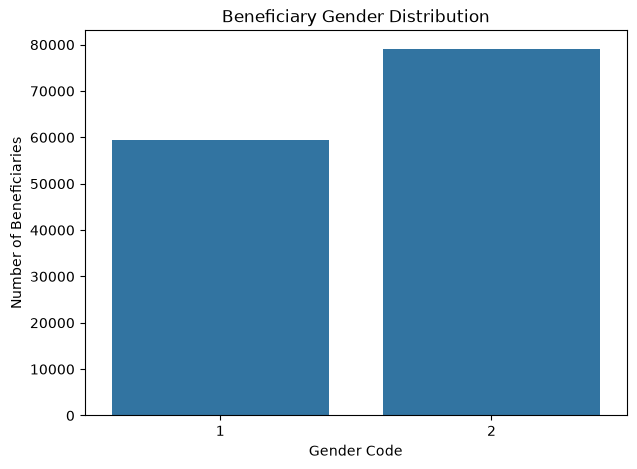

In [62]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=beneficiary_df,
    x="Gender"
)

plt.title("Beneficiary Gender Distribution")
plt.xlabel("Gender Code")
plt.ylabel("Number of Beneficiaries")

plt.show()

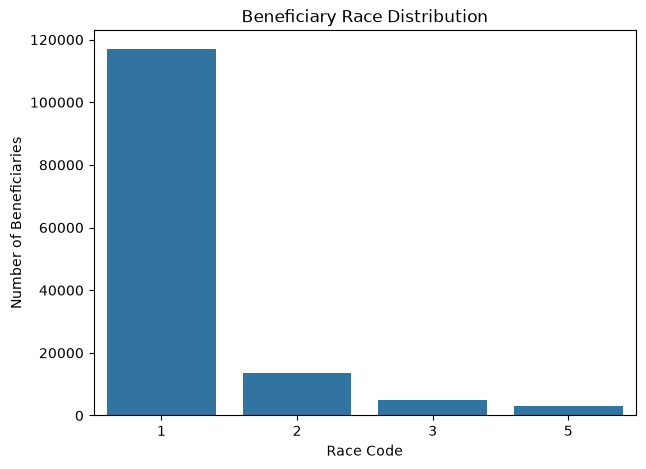

In [63]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=beneficiary_df,
    x="Race"
)

plt.title("Beneficiary Race Distribution")
plt.xlabel("Race Code")
plt.ylabel("Number of Beneficiaries")

plt.show()